# Fase 4 - Dashboard de inteligencia de negocios

Este notebook integra dos fuentes independientes para la Fase 4:

1. **Fuente de negocio**: API BDUA del régimen subsidiado (`d7a5-cnra`) consultada por JSON SODA2.
2. **Fuente bibliométrica**: subconjunto curado de resultados de **Web of Science** exportados a BibTeX y estandarizados a CSV.

El flujo cubre:
- carga y limpieza de datos,
- problemática de negocio,
- análisis bibliométrico,
- análisis de sentimiento sobre abstracts,
- modelado de tendencia de publicaciones,
- construcción de salidas para dashboard,
- interpretación estratégica y KPIs.


In [1]:
%pip install textblob
import re
import json
import math
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from textblob import TextBlob
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import networkx as nx

BASE_DIR = Path(".")
FUENTES_DIR = BASE_DIR / "fuentes"
SALIDAS_DIR = BASE_DIR / "salidas"
FIG_DIR = SALIDAS_DIR / "figuras"

FUENTES_DIR.mkdir(exist_ok=True)
SALIDAS_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

WOS_CSV = FUENTES_DIR / "wos_curado_fase4.csv"
WOS_BIB = FUENTES_DIR / "ReferenciasFase4_curadas.bib"
BDUA_URL = "https://www.datos.gov.co/resource/d7a5-cnra.json"

print(f"Notebook raíz: {BASE_DIR.resolve()}")
print(f"Carpeta de fuentes: {FUENTES_DIR.resolve()}")
print(f"Carpeta de salidas: {SALIDAS_DIR.resolve()}")
print(f"CSV WoS encontrado: {WOS_CSV.exists()}")
print(f"BIB WoS encontrado: {WOS_BIB.exists()}")

Note: you may need to restart the kernel to use updated packages.
Notebook raíz: C:\Users\Camilo\Documents\Maestría AO\Métodos cuantitativos\Fase 4\Fase4_Dashboard
Carpeta de fuentes: C:\Users\Camilo\Documents\Maestría AO\Métodos cuantitativos\Fase 4\Fase4_Dashboard\fuentes
Carpeta de salidas: C:\Users\Camilo\Documents\Maestría AO\Métodos cuantitativos\Fase 4\Fase4_Dashboard\salidas
CSV WoS encontrado: True
BIB WoS encontrado: True


## 1. Carga del corpus bibliográfico curado de Web of Science

In [2]:
wos = pd.read_csv(WOS_CSV)
wos.head(3)


,_key,title,author,year,journal,abstract,keywords,keywords-plus,doi,wos_times_cited,relevance_score,web-of-science-categories,country_focus,document_type,cited-references,sentiment_polarity,sentiment_label
0,WOS:000394108100001,State budget transfers to Health Insurance to ...,"Mathauer, Inke and Behrendt, Thorsten",2017,BMC HEALTH SERVICES RESEARCH,Background: Contributory social health insuran...,Universal health coverage; Vulnerable populati...,INSTITUTIONAL DESIGN; SOCIAL PROTECTION; FUNDS...,10.1186/s12913-017-2004-y,25,21,Health Care Sciences \& Services,Latin America,Article,"Acevedo O, 2013, UNIVERSAL HLTH COVER, V15. {[...",0.043746,Neutro
1,WOS:000448480100009,Leaving no one behind? Reaching the informal s...,"Meyer, Claude and Evans, David and Soucat, Agn...",2018,JOURNAL OF POVERTY AND SOCIAL JUSTICE,Among the various imperatives implicit in movi...,NaN,NaN,10.1332/175982718X15361436867390,2,15,"Social Issues; Social Sciences, Interdisciplinary",Multi-country,Article,"{[}Anonymous], EMPOWERING MARGINALI. {[}Anonym...",-0.042870,Neutro
2,WOS:000807902600001,Integrating Venezuelan Migrants into the Colom...,"Bowser, Diana M. and Agarwal-Harding, Priya an...",2022,HEALTH SYSTEMS \& REFORM,Colombia provides a unique setting to understa...,Access and equality; COVID-19; health system; ...,CARE,10.1080/23288604.2022.2079448,20,14,"Health Policy \& Services; Public, Environment...",Colombia,Article,"Abubakar I, 2018, LANCET, V392, P2606, DOI 10....",-0.011538,Neutro


## 2. Perfil básico del corpus

In [3]:
perfil = {
    "registros": len(wos),
    "periodo_min": int(wos["year"].min()),
    "periodo_max": int(wos["year"].max()),
    "times_cited_promedio": float(wos["wos_times_cited"].mean()),
    "fuentes_distintas": int(wos["journal"].nunique())
}
perfil


{'registros': 24,
 'periodo_min': 2016,
 'periodo_max': 2026,
 'times_cited_promedio': 9.375,
 'fuentes_distintas': 18}

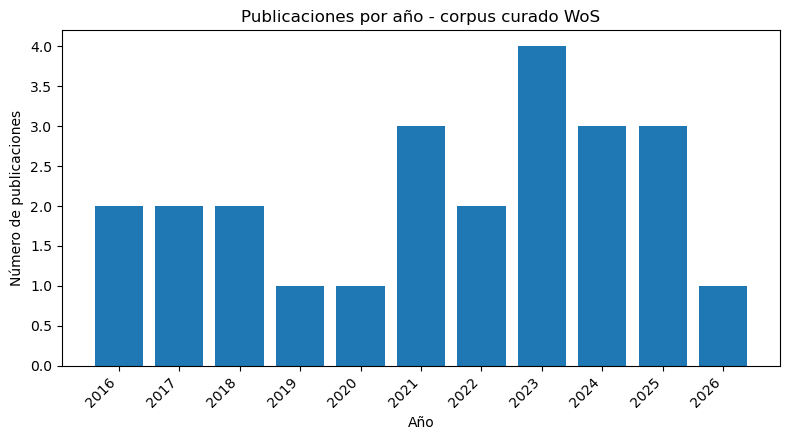

Guardado: salidas\figuras\publicaciones_por_anio.png


In [4]:
pubs = wos.groupby("year").size().reset_index(name="total").sort_values("year")
plt.figure(figsize=(8,4.5))
plt.bar(pubs["year"].astype(str), pubs["total"])
plt.xticks(rotation=45, ha="right")
plt.title("Publicaciones por año - corpus curado WoS")
plt.xlabel("Año")
plt.ylabel("Número de publicaciones")
plt.tight_layout()
out_path = FIG_DIR / "publicaciones_por_anio.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Guardado: {out_path}")

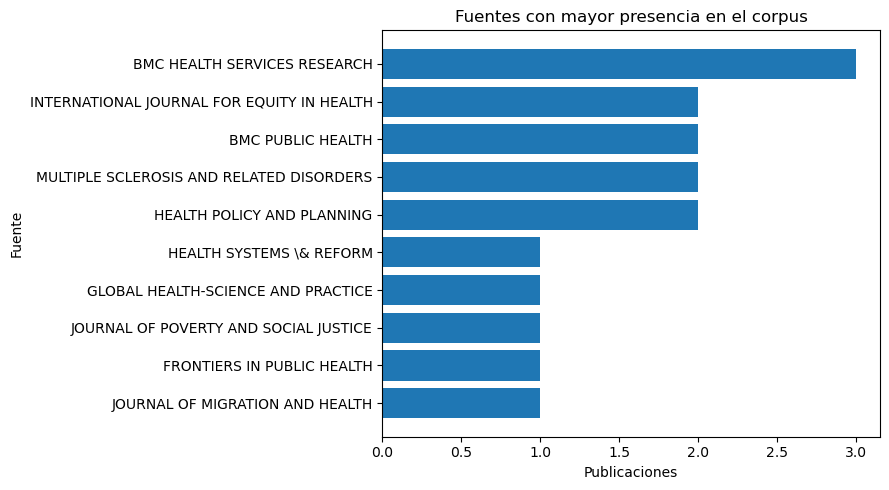

Guardado: salidas\figuras\top_fuentes.png


In [5]:
fuentes_top = wos["journal"].value_counts().head(10).sort_values()
plt.figure(figsize=(9,5))
plt.barh(fuentes_top.index, fuentes_top.values)
plt.title("Fuentes con mayor presencia en el corpus")
plt.xlabel("Publicaciones")
plt.ylabel("Fuente")
plt.tight_layout()
out_path = FIG_DIR / "top_fuentes.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Guardado: {out_path}")

## 3. Palabras clave dominantes

In [6]:
def split_keywords(s):
    if pd.isna(s):
        return []
    return [p.strip().lower() for p in re.split(r";|,", str(s)) if p.strip()]

kw = Counter()
for s in wos["keywords"].fillna(""):
    kw.update(split_keywords(s))

topkw = pd.DataFrame(kw.most_common(12), columns=["keyword", "total"])
topkw


,keyword,total
0,colombia,8
1,universal health coverage,3
2,latin america,3
3,health insurance,3
4,integration,2
5,venezuelan migrants,2
6,policy,2
7,global health,2
8,mexico,2
9,social determinants of health,2


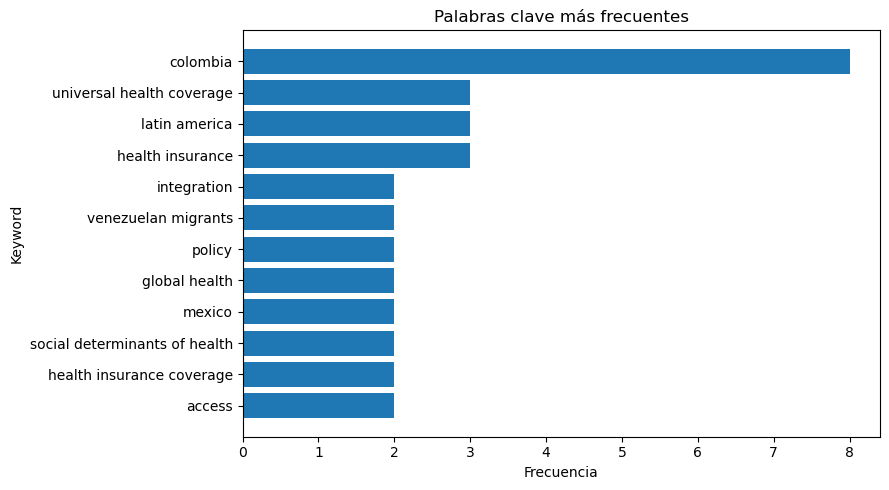

Guardado: salidas\figuras\top_keywords.png
Guardado: salidas\top_keywords.csv


In [7]:
plt.figure(figsize=(9,5))
plt.barh(topkw["keyword"][::-1], topkw["total"][::-1])
plt.title("Palabras clave más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Keyword")
plt.tight_layout()
out_path = FIG_DIR / "top_keywords.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Guardado: {out_path}")

topkw.to_csv(SALIDAS_DIR / "top_keywords.csv", index=False)
print(f"Guardado: {SALIDAS_DIR / 'top_keywords.csv'}")

## 4. Sentimiento sobre abstracts

In [8]:
if "sentiment_polarity" not in wos.columns:
    wos["sentiment_polarity"] = wos["abstract"].fillna("").apply(lambda t: TextBlob(str(t)).sentiment.polarity)
if "sentiment_label" not in wos.columns:
    wos["sentiment_label"] = pd.cut(
        wos["sentiment_polarity"],
        bins=[-1, -0.05, 0.05, 1],
        labels=["Negativo", "Neutro", "Positivo"],
        include_lowest=True
    )

wos[["title", "sentiment_polarity", "sentiment_label"]].head()


,title,sentiment_polarity,sentiment_label
0,State budget transfers to Health Insurance to ...,0.043746,Neutro
1,Leaving no one behind? Reaching the informal s...,-0.042870,Neutro
2,Integrating Venezuelan Migrants into the Colom...,-0.011538,Neutro
3,Relationship between universal health insuranc...,-0.102763,Negativo
4,Family Planning in the Context of Latin Americ...,0.087752,Positivo


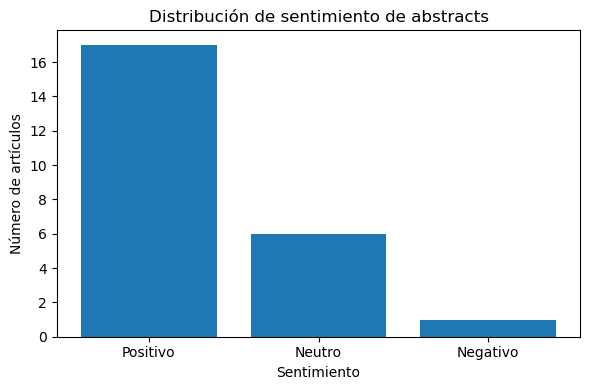

Guardado: salidas\figuras\sentimiento_distribucion.png


In [9]:
sent_counts = wos["sentiment_label"].astype(str).value_counts()
plt.figure(figsize=(6,4))
plt.bar(sent_counts.index, sent_counts.values)
plt.title("Distribución de sentimiento de abstracts")
plt.xlabel("Sentimiento")
plt.ylabel("Número de artículos")
plt.tight_layout()
out_path = FIG_DIR / "sentimiento_distribucion.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Guardado: {out_path}")

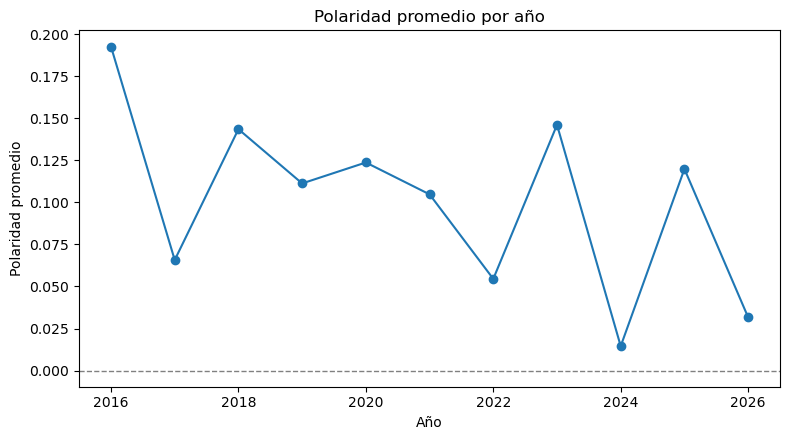

Guardado: salidas\figuras\sentimiento_por_anio.png
Guardado: salidas\sentimiento_por_anio.csv


In [10]:
sent_year = wos.groupby("year", as_index=False)["sentiment_polarity"].mean().sort_values("year")
plt.figure(figsize=(8,4.5))
plt.plot(sent_year["year"], sent_year["sentiment_polarity"], marker="o")
plt.axhline(0, linestyle="--", color="gray", linewidth=1)
plt.title("Polaridad promedio por año")
plt.xlabel("Año")
plt.ylabel("Polaridad promedio")
plt.tight_layout()
out_path = FIG_DIR / "sentimiento_por_anio.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Guardado: {out_path}")

sent_year.to_csv(SALIDAS_DIR / "sentimiento_por_anio.csv", index=False)
print(f"Guardado: {SALIDAS_DIR / 'sentimiento_por_anio.csv'}")

## 5. Probabilidad y machine learning sobre tendencia de publicaciones

Se usa una distribución normal para explorar la densidad de `times cited` y una regresión lineal para proyectar publicaciones.


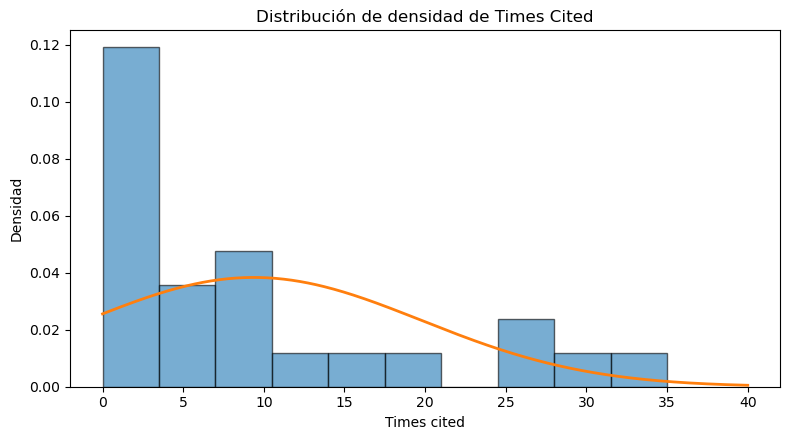

Guardado: salidas\figuras\pdf_times_cited.png


In [11]:
cit = wos["wos_times_cited"].fillna(0).astype(float).values
mu = cit.mean()
sigma = cit.std(ddof=1) if len(cit) > 1 else 1

xs = np.linspace(max(0, cit.min()-1), cit.max()+5, 400)
pdf = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((xs-mu)/sigma)**2) if sigma > 0 else np.zeros_like(xs)

plt.figure(figsize=(8,4.5))
plt.hist(cit, bins=min(10, len(cit)), density=True, alpha=0.6, edgecolor="black")
plt.plot(xs, pdf, linewidth=2)
plt.title("Distribución de densidad de Times Cited")
plt.xlabel("Times cited")
plt.ylabel("Densidad")
plt.tight_layout()
out_path = FIG_DIR / "pdf_times_cited.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Guardado: {out_path}")

In [12]:
X = pubs[["year"]].values
y = pubs["total"].values

model = LinearRegression().fit(X, y)
pred_hist = model.predict(X)

future_years = np.arange(int(pubs["year"].max())+1, int(pubs["year"].max())+6).reshape(-1,1)
future_pred = model.predict(future_years)

mae = mean_absolute_error(y, pred_hist)
mse = mean_squared_error(y, pred_hist)
rmse = np.sqrt(mse)
r2 = r2_score(y, pred_hist)

forecast_df = pd.DataFrame({
    "year": future_years.flatten(),
    "forecast_publications": np.round(future_pred, 2)
})
forecast_path = SALIDAS_DIR / "forecast_publicaciones.csv"
forecast_df.to_csv(forecast_path, index=False)

metricas = pd.DataFrame([{"mae": mae, "rmse": rmse, "r2": r2}])
metricas_path = SALIDAS_DIR / "metricas_modelo.csv"
metricas.to_csv(metricas_path, index=False)

print({"MAE": round(mae, 3), "RMSE": round(rmse, 3), "R2": round(r2, 3)})
print(f"Guardado: {forecast_path}")
print(f"Guardado: {metricas_path}")
forecast_df

{'MAE': 0.722, 'RMSE': np.float64(0.899), 'R2': 0.076}
Guardado: salidas\forecast_publicaciones.csv
Guardado: salidas\metricas_modelo.csv


,year,forecast_publications
0,2027,2.67
1,2028,2.75
2,2029,2.84
3,2030,2.92
4,2031,3.00


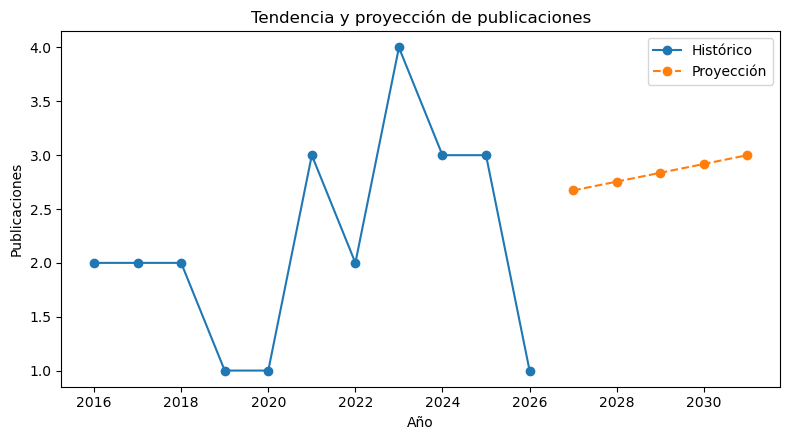

Guardado: salidas\figuras\forecast_publicaciones.png


In [13]:
plt.figure(figsize=(8,4.5))
plt.plot(pubs["year"], pubs["total"], marker="o", label="Histórico")
plt.plot(future_years, future_pred, marker="o", linestyle="--", label="Proyección")
plt.title("Tendencia y proyección de publicaciones")
plt.xlabel("Año")
plt.ylabel("Publicaciones")
plt.legend()
plt.tight_layout()
out_path = FIG_DIR / "forecast_publicaciones.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Guardado: {out_path}")

## 6. Red exploratoria de co-citación

A partir del campo `cited-references` del BibTeX se construye una red exploratoria con los referentes más frecuentes.


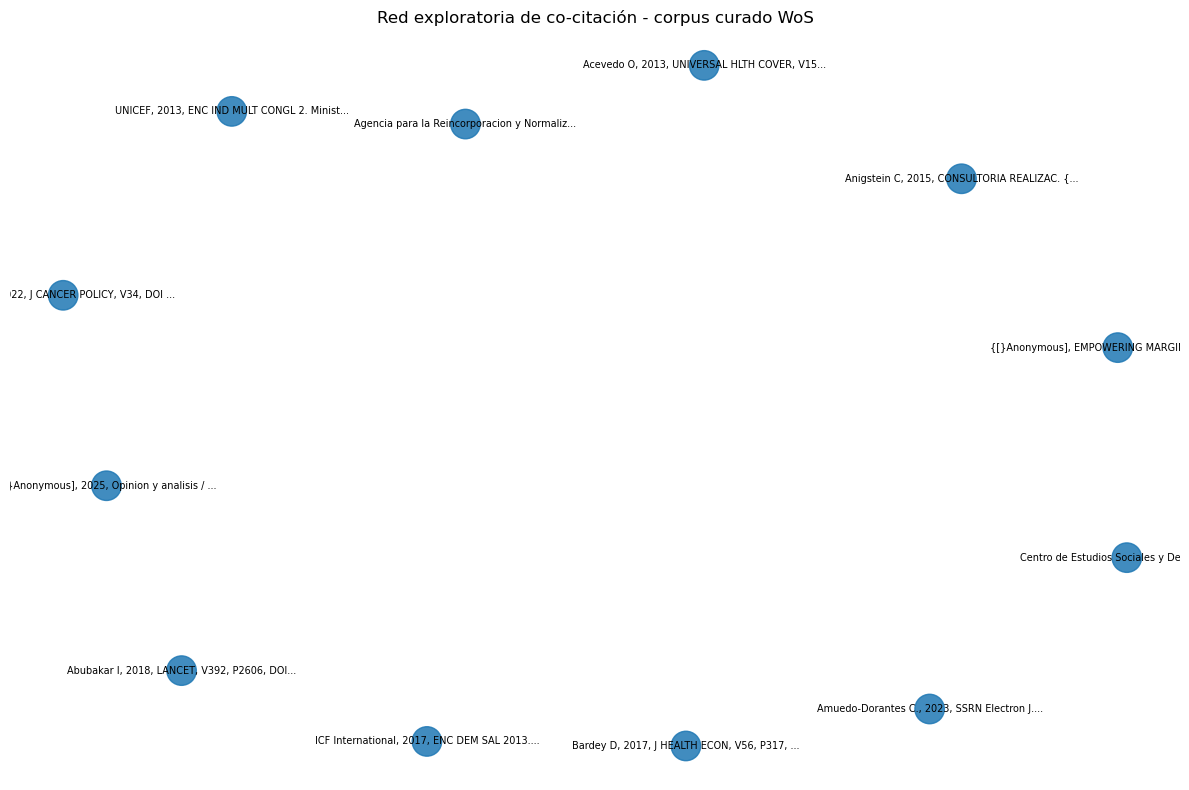

Guardado: salidas\figuras\red_cocitacion_exploratoria.png


In [14]:
ref_counter = Counter()
pair_counter = Counter()

for refs in wos["cited-references"].fillna(""):
    parts = [re.sub(r"\s+", " ", r.strip()) for r in re.split(r";\s*(?=[A-Z])", str(refs)) if r.strip()]
    parts = [p[:120] for p in parts]
    unique = list(dict.fromkeys(parts))
    ref_counter.update(unique)
    for i in range(len(unique)):
        for j in range(i+1, len(unique)):
            pair_counter[tuple(sorted((unique[i], unique[j])))] += 1

top_refs = {r for r, c in ref_counter.most_common(12)}

G = nx.Graph()
for r, c in ref_counter.items():
    if r in top_refs:
        G.add_node(r, count=c)

for (a, b), w in pair_counter.items():
    if a in top_refs and b in top_refs and w >= 2:
        G.add_edge(a, b, weight=w)

plt.figure(figsize=(12,8))
if G.number_of_nodes():
    pos = nx.spring_layout(G, seed=42, k=1.3)
    nx.draw_networkx_nodes(G, pos, node_size=[250 + 200*G.nodes[n]["count"] for n in G.nodes], alpha=0.85)
    nx.draw_networkx_edges(G, pos, width=[0.8 + G[u][v]["weight"] for u,v in G.edges], alpha=0.35)
    labels = {n: (n[:42] + "...") if len(n) > 42 else n for n in G.nodes}
    nx.draw_networkx_labels(G, pos, labels, font_size=7)
    plt.title("Red exploratoria de co-citación - corpus curado WoS")
    plt.axis("off")
else:
    plt.text(0.5, 0.5, "No se pudo construir la red", ha="center", va="center")
    plt.axis("off")
plt.tight_layout()
out_path = FIG_DIR / "red_cocitacion_exploratoria.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Guardado: {out_path}")

## 7. Fuente de negocio BDUA por API SODA2

Esta fase es independiente de la Fase 3. El notebook usa la API de BDUA como fuente operativa de negocio.  
Las siguientes celdas están listas para consultar la API cuando tengas conexión.


In [15]:
def consulta_bdua(select, group=None, where=None, order=None, limit=50000):
    params = {"$select": select, "$limit": str(limit)}
    if group:
        params["$group"] = group
    if where:
        params["$where"] = where
    if order:
        params["$order"] = order
    resp = requests.get(BDUA_URL, params=params, timeout=60)
    resp.raise_for_status()
    data = resp.json()
    return pd.DataFrame(data)

# Ejemplo 1: total por departamento
# dpto = consulta_bdua(select="dpr_nombre, sum(cantidad) as total", group="dpr_nombre", order="total DESC", limit=1000)
# dpto.head()

# Ejemplo 2: total por grupo etario y género
# grp = consulta_bdua(select="tps_grp_etr_id, tps_gnr_nombre, sum(cantidad) as total", group="tps_grp_etr_id, tps_gnr_nombre", limit=5000)
# grp.head()


## 8. Problemática de negocio sugerida

**Problema:** la asignación de esfuerzos de aseguramiento y gestión territorial puede ser ineficiente si no se identifican con claridad los segmentos poblacionales, territorios y actores con mayor concentración de afiliados del régimen subsidiado y si no se conectan esos hallazgos con tendencias de acceso, cobertura y equidad reportadas por la literatura científica.

**Pregunta orientadora:** ¿cómo priorizar estrategias territoriales y poblacionales de aseguramiento a partir de la estructura actual del BDUA y de la evidencia científica sobre cobertura, acceso e inequidad?


## 9. Estrategias y KPIs

### Estrategias
1. Priorizar departamentos y municipios con mayor concentración de afiliados para focalizar acciones operativas.
2. Diseñar intervenciones específicas por grupo etario y género.
3. Incorporar acciones diferenciales para poblaciones vulnerables y migrantes.
4. Fortalecer telemedicina y acceso en zonas rurales o dispersas.

### KPIs sugeridos
- Participación porcentual de afiliados por departamento.
- Participación porcentual por EPS.
- Índice de concentración territorial de afiliados.
- Proporción de afiliados por grupo etario.
- Variación anual de publicaciones sobre cobertura y acceso.
- Polaridad promedio de abstracts por año.


## 10. Interpretación estratégica para el dashboard

El corpus curado sugiere que la discusión científica reciente se concentra en cobertura, acceso efectivo, inequidades, migración y desempeño de sistemas de aseguramiento en América Latina, con fuerte presencia de evidencia de Colombia y México. Si la estructura del BDUA confirma concentraciones territoriales y poblacionales, la decisión estratégica más razonable es priorizar intervenciones en los segmentos más expuestos a barreras de acceso y complementar el aseguramiento con modelos diferenciales de gestión territorial, telemedicina, continuidad del cuidado y enfoque de equidad.


## 11. Resumen de archivos generados

In [16]:
generados = sorted([str(p.relative_to(BASE_DIR)) for p in SALIDAS_DIR.rglob("*") if p.is_file()])
pd.DataFrame({"archivo_generado": generados})

,archivo_generado
0,salidas\figuras\forecast_publicaciones.png
1,salidas\figuras\pdf_times_cited.png
2,salidas\figuras\publicaciones_por_anio.png
3,salidas\figuras\red_cocitacion_exploratoria.png
4,salidas\figuras\sentimiento_distribucion.png
5,salidas\figuras\sentimiento_por_anio.png
6,salidas\figuras\top_fuentes.png
7,salidas\figuras\top_keywords.png
8,salidas\forecast_publicaciones.csv
9,salidas\metricas_modelo.csv


In [17]:
from pathlib import Path

print("Carpeta actual:", Path(".").resolve())
print("Salidas existe:", (Path(".") / "salidas").exists())
print("Figuras existe:", (Path(".") / "salidas" / "figuras").exists())

Carpeta actual: C:\Users\Camilo\Documents\Maestría AO\Métodos cuantitativos\Fase 4\Fase4_Dashboard
Salidas existe: True
Figuras existe: True


In [18]:
from pathlib import Path

for p in sorted((Path(".") / "salidas").glob("**/*")):
    print(p)

salidas\figuras
salidas\figuras\forecast_publicaciones.png
salidas\figuras\pdf_times_cited.png
salidas\figuras\publicaciones_por_anio.png
salidas\figuras\red_cocitacion_exploratoria.png
salidas\figuras\sentimiento_distribucion.png
salidas\figuras\sentimiento_por_anio.png
salidas\figuras\top_fuentes.png
salidas\figuras\top_keywords.png
salidas\forecast_publicaciones.csv
salidas\metricas_modelo.csv
salidas\sentimiento_por_anio.csv
salidas\top_keywords.csv
